# 01 — Exploratory Data Analysis (Cleveland Heart Disease)

**Dataset**: UCI Heart Disease — Cleveland subset (`data/heart+disease/processed.cleveland.data`).

Per the dataset README, only Cleveland is used by the published ML literature. This notebook covers:
1. Loading the raw data with the documented schema
2. Quality checks: missing values, dtypes, duplicates
3. Target distribution (binary: presence vs absence of disease)
4. Univariate distributions (numeric + categorical)
5. Bivariate views vs the target
6. Correlation heatmap
7. Persisted EDA artifacts under `artifacts/figures/eda/`

In [12]:
%pip install -q numpy matplotlib seaborn pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from __future__ import annotations
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd().name == 'notebooks') else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from heart_disease_mlops.config import (
    CATEGORICAL_FEATURES, NUMERIC_FEATURES, FEATURE_DESCRIPTIONS,
    RAW_TARGET, TARGET, FIGURES_DIR, ensure_dirs,
)
from heart_disease_mlops.data import load_raw_cleveland, clean_cleveland

ensure_dirs()
EDA_FIG_DIR = FIGURES_DIR / 'eda'
EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
print('Project root:', PROJECT_ROOT)

Project root: C:\Users\anabhart\OneDrive - Cisco\Desktop\MLOPS


## 1. Load raw data

In [14]:
raw = load_raw_cleveland()
print('Shape:', raw.shape)
raw.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [15]:
raw.dtypes.to_frame('dtype').assign(description=lambda d: d.index.map(FEATURE_DESCRIPTIONS))

,dtype,description
age,float64,Age in years
sex,float64,"Sex (1 = male, 0 = female)"
cp,float64,"Chest pain type (1=typical, 2=atypical, 3=non-..."
trestbps,float64,Resting blood pressure (mm Hg)
chol,float64,Serum cholesterol (mg/dl)
fbs,float64,"Fasting blood sugar > 120 mg/dl (1=true, 0=false)"
restecg,float64,"Resting ECG (0=normal, 1=ST-T abnormality, 2=L..."
thalach,float64,Maximum heart rate achieved
exang,float64,"Exercise induced angina (1=yes, 0=no)"
oldpeak,float64,ST depression induced by exercise relative to ...


## 2. Quality checks

In [16]:
missing = raw.isna().sum()
missing[missing > 0].to_frame('missing')

,missing
ca,4
thal,2


In [17]:
print('Duplicate rows:', int(raw.duplicated().sum()))
print('Rows with any NA:', int(raw.isna().any(axis=1).sum()))

Duplicate rows: 0
Rows with any NA: 6


Only `ca` and `thal` carry missing values (encoded as `?` in the source). We drop the affected rows — fewer than ~2% of the sample — and derive the binary target.

In [18]:
df = clean_cleveland(raw)
print('Cleaned shape:', df.shape)
df.head()

Cleaned shape: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0


## 3. Target distribution

We compare the **raw severity grade** (`num`, 0-4) with the **binary target** used downstream.

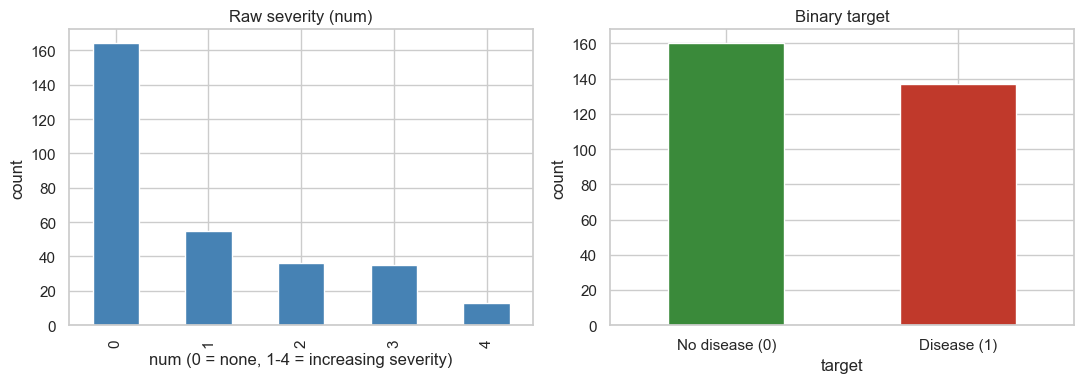

Class balance:
target
0    0.539
1    0.461
Name: proportion, dtype: float64


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
raw[RAW_TARGET].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Raw severity (num)')
axes[0].set_xlabel('num (0 = none, 1-4 = increasing severity)')
axes[0].set_ylabel('count')

df[TARGET].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['#3a8a3a', '#c0392b'])
axes[1].set_xticklabels(['No disease (0)', 'Disease (1)'], rotation=0)
axes[1].set_title('Binary target')
axes[1].set_ylabel('count')
fig.tight_layout()
fig.savefig(EDA_FIG_DIR / 'target_distribution.png', dpi=150)
plt.show()

print('Class balance:')
print(df[TARGET].value_counts(normalize=True).round(3))

The classes are roughly balanced (~54% / 46%), so we can use accuracy and ROC-AUC without major reweighting.

## 4. Univariate distributions

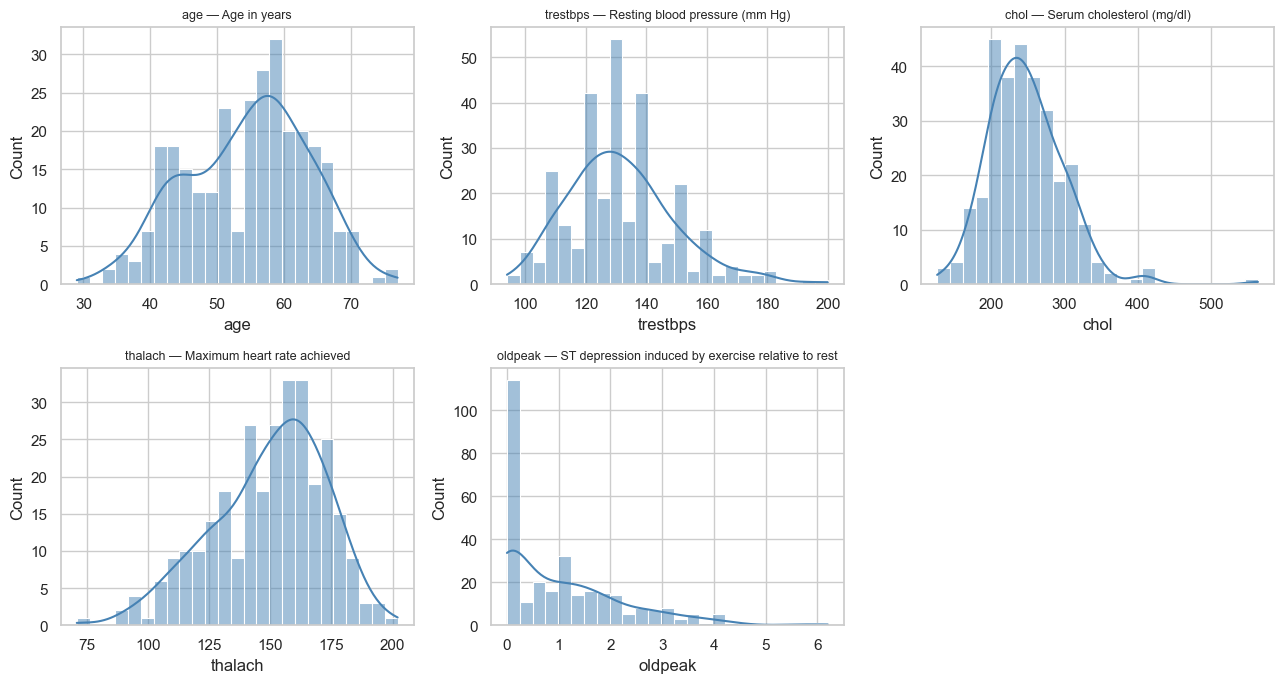

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, NUMERIC_FEATURES + ['']):
    if col == '':
        ax.axis('off')
        continue
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=25)
    ax.set_title(f'{col} — {FEATURE_DESCRIPTIONS[col]}', fontsize=9)
fig.tight_layout()
fig.savefig(EDA_FIG_DIR / 'numeric_distributions.png', dpi=150)
plt.show()

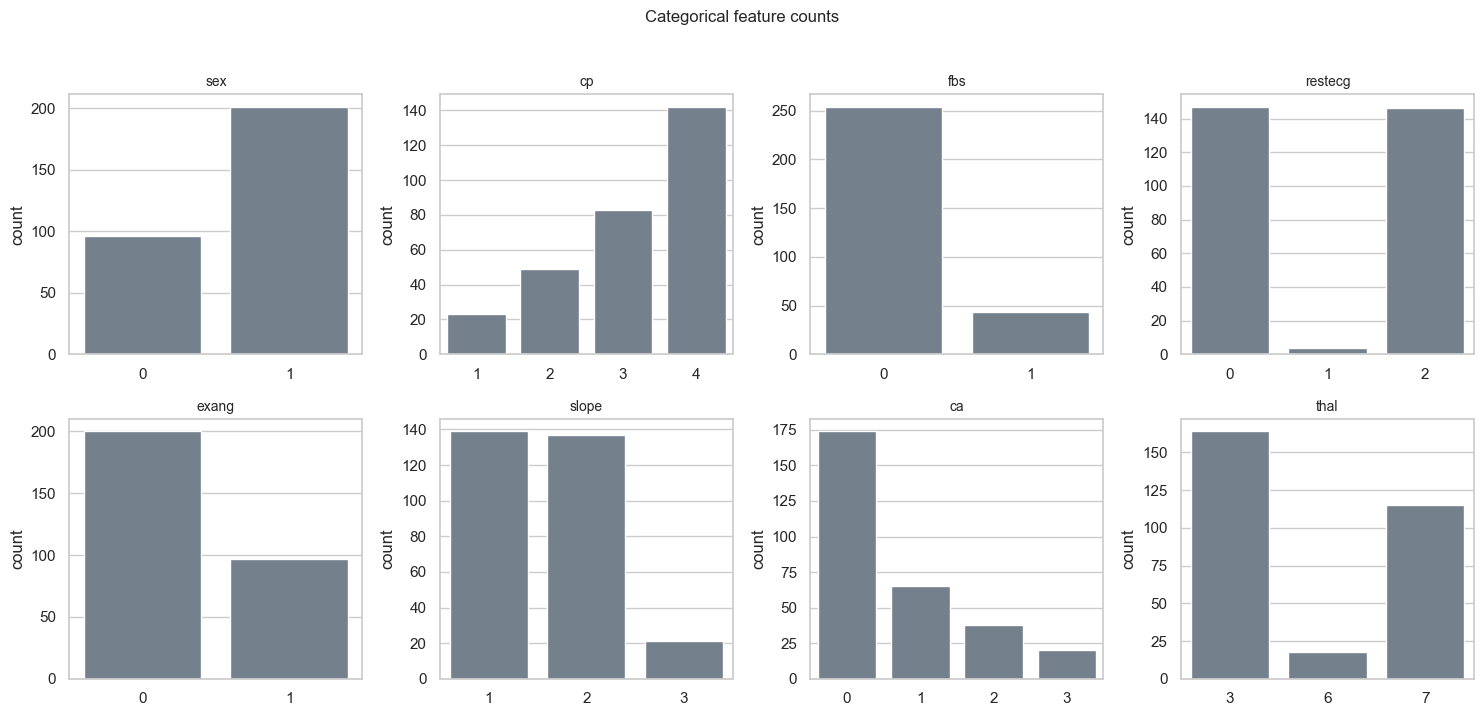

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, col in zip(axes.flat, CATEGORICAL_FEATURES):
    counts = df[col].value_counts().sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, color='slategray')
    ax.set_title(f'{col}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('count')
fig.suptitle('Categorical feature counts', y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(EDA_FIG_DIR / 'categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Bivariate views vs the target

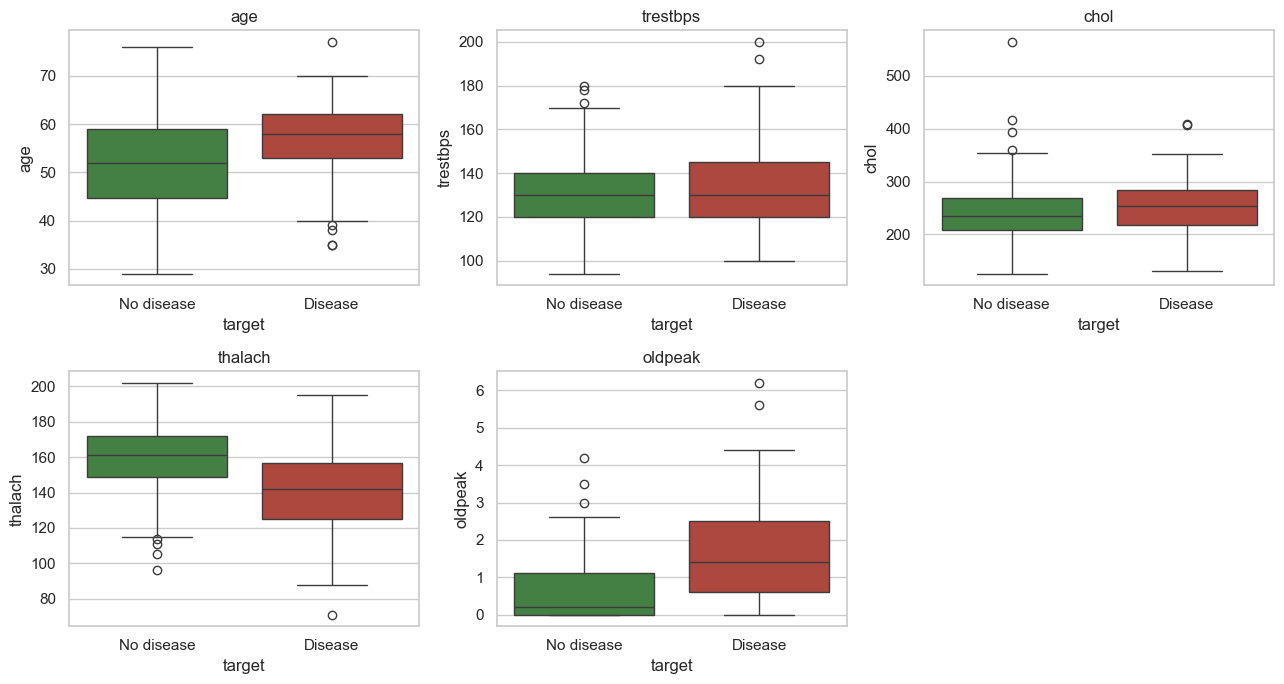

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, NUMERIC_FEATURES + ['']):
    if col == '':
        ax.axis('off')
        continue
    sns.boxplot(
        data=df, x=TARGET, y=col, ax=ax,
        hue=TARGET, palette={0: '#3a8a3a', 1: '#c0392b'}, legend=False,
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No disease', 'Disease'])
    ax.set_title(col)
fig.tight_layout()
fig.savefig(EDA_FIG_DIR / 'numeric_vs_target.png', dpi=150)
plt.show()

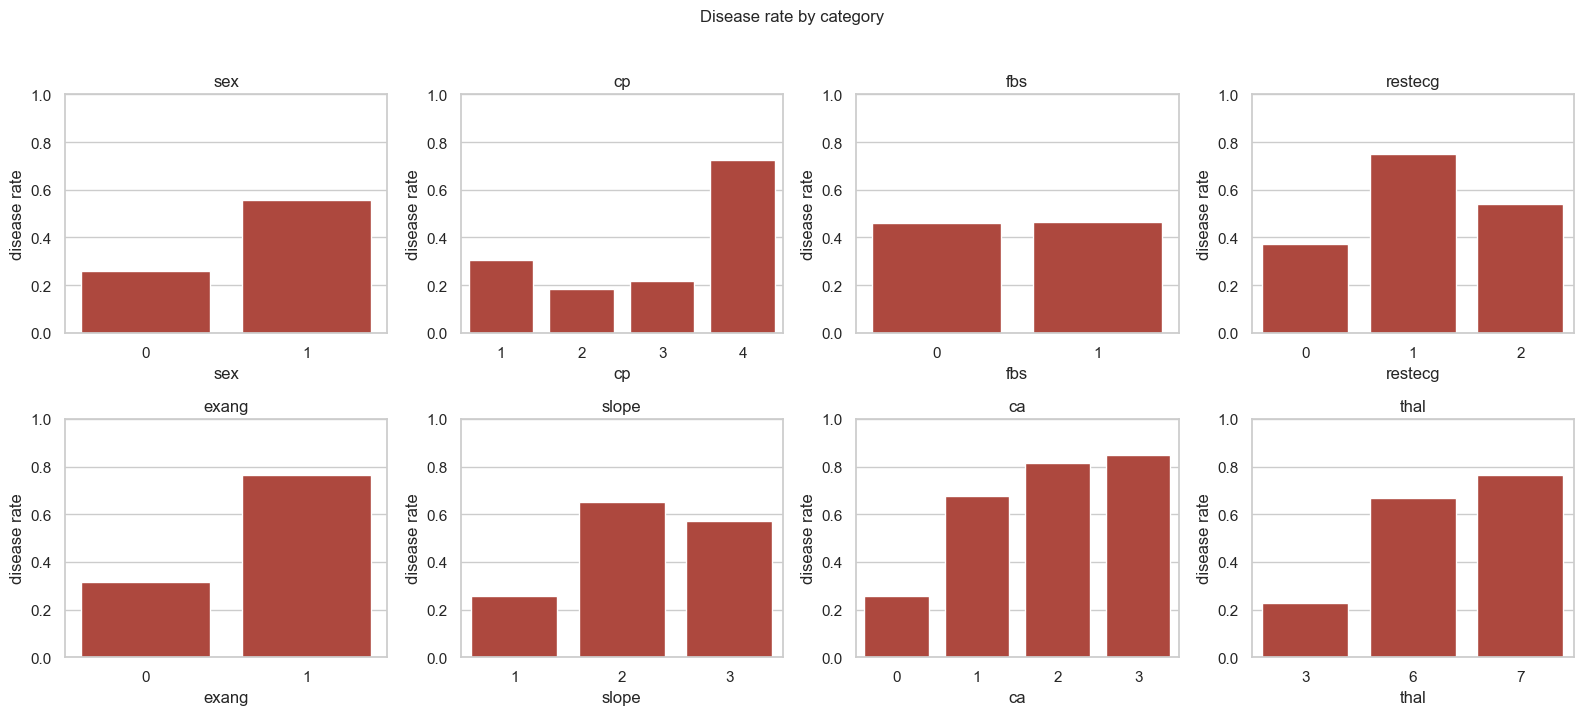

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, CATEGORICAL_FEATURES):
    rate = df.groupby(col)[TARGET].mean().sort_index()
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, color='#c0392b')
    ax.set_ylim(0, 1)
    ax.set_ylabel('disease rate')
    ax.set_title(col)
fig.suptitle('Disease rate by category', y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(EDA_FIG_DIR / 'category_disease_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation heatmap

Categorical columns are encoded as integer codes; correlations are indicative only. Strong absolute correlations with the target highlight likely predictive features.

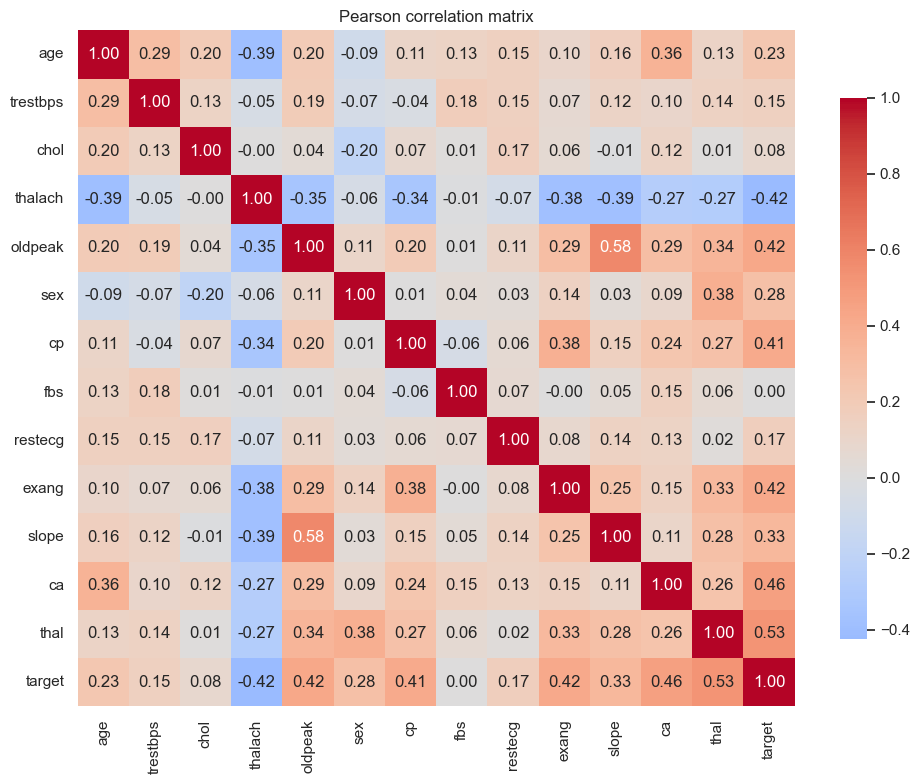

In [24]:
corr = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Pearson correlation matrix')
fig.tight_layout()
fig.savefig(EDA_FIG_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()

In [25]:
target_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
target_corr.to_frame('corr_with_target')

,corr_with_target
thal,0.526640
ca,0.463189
oldpeak,0.424052
thalach,-0.423817
exang,0.421355
cp,0.408945
slope,0.333049
sex,0.278467
age,0.227075
restecg,0.166343


## 7. Summary statistics

In [26]:
df[NUMERIC_FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.54,9.05,29.0,48.0,56.0,61.0,77.0
trestbps,297.0,131.69,17.76,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.35,52.00,126.0,211.0,243.0,276.0,564.0
thalach,297.0,149.60,22.94,71.0,133.0,153.0,166.0,202.0
oldpeak,297.0,1.06,1.17,0.0,0.0,0.8,1.6,6.2


### Key takeaways
* **303 raw rows → ~297 after dropping 6 NA rows** in `ca` / `thal`.
* Binary target is roughly balanced (~54% / 46%).
* Strongest correlates with disease: `cp` (chest-pain type), `thalach` (max heart rate, negative), `oldpeak`, `exang`, `ca`, `thal`.
* Numeric features have different scales → standard scaling is required for distance-based / linear models.
* Categorical codes (`cp`, `restecg`, `slope`, `thal`, `ca`) are not ordinal in any clean way → one-hot encoding is preferred.

These observations drive the preprocessing pipeline in `src/heart_disease_mlops/preprocessing.py`.